In [16]:
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn import preprocessing
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from collections import defaultdict
from pathlib import Path

#### Specify the time periods.

In [17]:
discharge_coverage_path = Path("~/BA/data/processed_data/eda/discharge_coverage.pkl")

discharge_coverage = pd.read_pickle(discharge_coverage_path)

##### Visualize normal periods for a subsample of basins. 

Basin 55 is the odd one out, it shows systematic gaps, and is therefore not usable.

In [18]:
min_normal_len = 180 

In [19]:
#fig, ax = plt.subplots(figsize=(10, len(discharge_coverage) * 0.25))
#
#yticks = []
#yticklabels = []
#
## Test pickling. 
#train_dict = defaultdict(dict)
#val_dict = defaultdict(dict)
#test_dict = defaultdict(dict)
#
#for basin in discharge_coverage.itertuples():
#
#    basin_dict = {
#        "start_dates": [],
#        "end_dates" : []
#    }
#    normal_periods = []
#
#    for period in basin[-2]: 
#
#        x_min = period[0]
#        x_width = (period[1] - period[0])
#
#        if x_width.days > min_normal_len: 
#            normal_periods.append((x_min,x_width))
#
#            # Attach for pickling. 
#            basin_dict["start_dates"].append(period[0])
#            basin_dict["end_dates"].append(period[1])
#
#    ax.broken_barh(
#        xranges=normal_periods,
#        yrange=(len(yticks), 0.5)
#    )
#
#    basin_id = basin[0]
#
#    if len(basin_dict["end_dates"]) != 0: 
#
#        if basin_id < 600:
#            train_dict[str(basin_id)] = basin_dict
#        elif basin_id < 750: 
#            val_dict[str(basin_id)] = basin_dict
#        else: 
#            test_dict[str(basin_id)] = basin_dict
#
#    yticks.append(len(yticks))
#    yticklabels.append(basin[0])
#
#ax.set_yticks(yticks)
#ax.set_yticklabels(yticklabels)
#ax.set_ylim(-1,len(yticks)+1)
#
#plt.tight_layout()
#plt.show()
#

In [20]:
n_samples = 0

for basin in discharge_coverage["q5_q95_normal_periods"]: 

    for period in basin: 

        duration = (period[1] - period[0]).days

        if duration >= min_normal_len:
            n_samples += duration

print(n_samples)

6129238


#### Specify the basin IDs.

In [21]:
# Remove NA & non-numeric columns and normalize.

scaler = preprocessing.MinMaxScaler()

attributes_shape_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/3_shapefiles/Basins_B.shp")
hydro_indices_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/D_gauges/1_attributes/Hydro_indices_1981_2017.csv")

basin_stca_gdf = gpd.read_file(attributes_shape_path)
basin_stca_gdf.set_index("ID", inplace=True)

# Drop Na and non-numeric columns, to prep for clustering.
no_na_df = basin_stca_gdf.dropna().sort_index()
numeric_df = no_na_df.select_dtypes(include=["number"])
scaled_df = pd.DataFrame(scaler.fit_transform(numeric_df.values), columns=numeric_df.columns)

# Also get hydro indices, to cluster basins based on that.
hydro_indices = pd.read_table(hydro_indices_path, header=0, sep=";")
hydro_indices.set_index("ID", inplace=True)

no_na_hy_id = hydro_indices.dropna()
numeric_hy_id = no_na_hy_id.select_dtypes(include=["number"])
scaled_hy_id = pd.DataFrame(scaler.fit_transform(numeric_hy_id.values), columns=numeric_hy_id.columns)

merged = numeric_df.join(numeric_hy_id,how="left").dropna()

In [22]:
# Apply PCA to minimise cocorrelation.

pca = PCA(n_components=0.8, svd_solver="full")
pca_df = pca.fit_transform(scaled_df)
pca_hy_id = pca.fit_transform(scaled_hy_id)


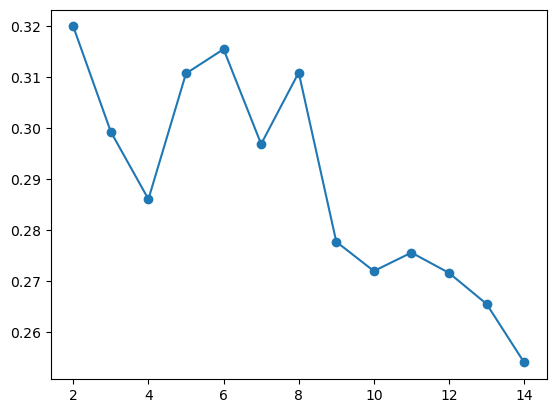

In [34]:

s_scores = []

for k in range(2,15):
    labels = KMeans(k,random_state=42).fit_predict(pca_df)
    s_scores.append(silhouette_score(pca_df,labels))

plt.plot(range(2,15), s_scores, marker="o")

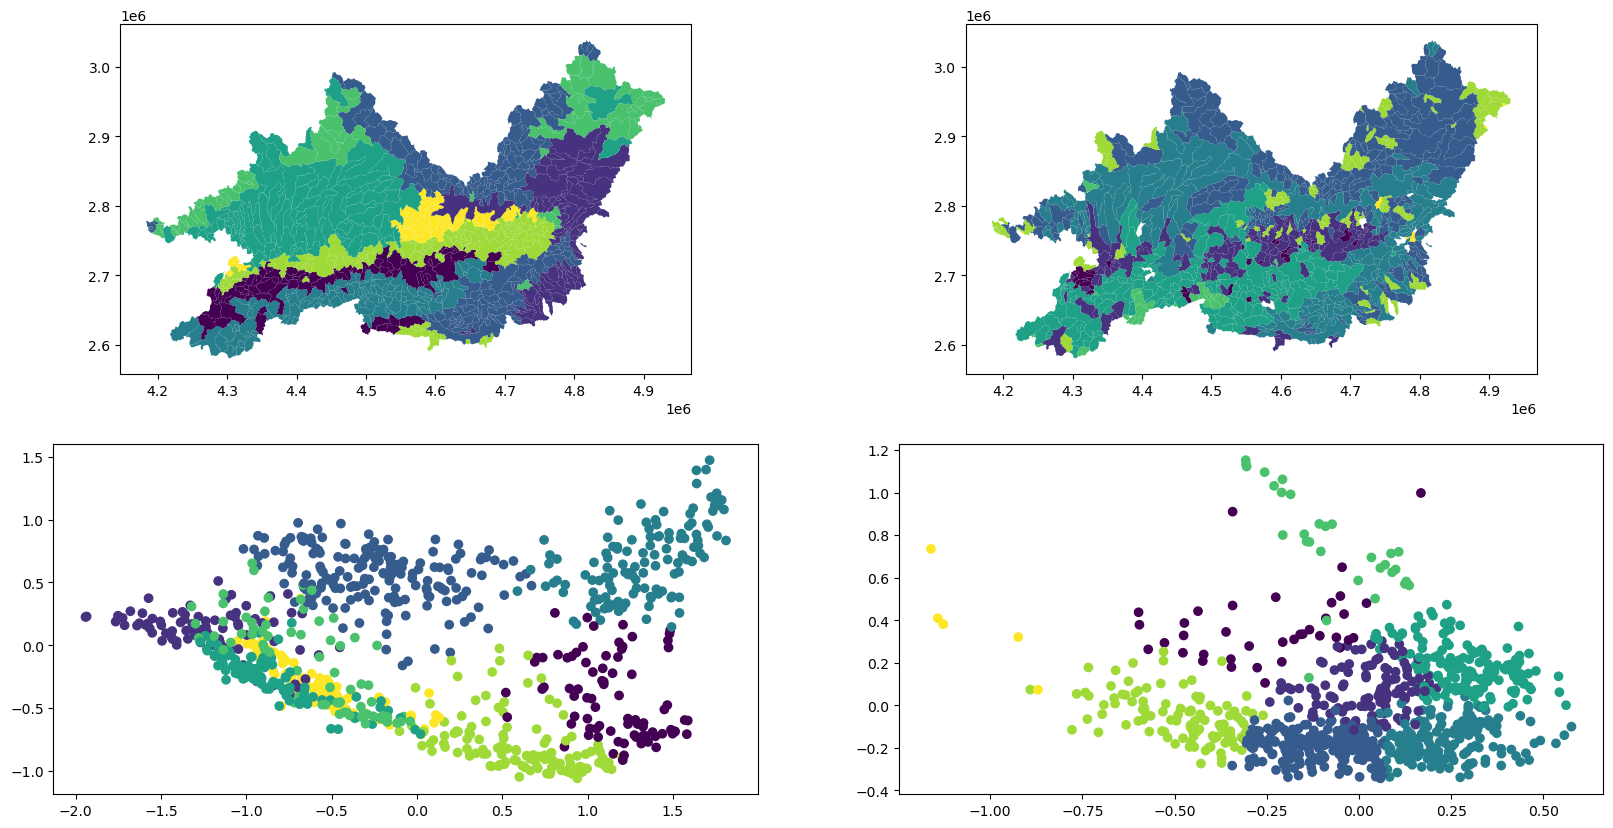

In [35]:
n_clusters = 8

cmap = mpl.colormaps["viridis"].resampled(n_clusters)

kmeans = KMeans(n_clusters=n_clusters, random_state=12)

kmeans.fit(pca_df)

basin_attr_kmeans_labels = pd.Series(kmeans.labels_,numeric_df.index)

plot_gdf = no_na_df.copy()
plot_gdf["cluster_attributes"] = basin_attr_kmeans_labels

kmeans.fit(pca_hy_id)

basin_hy_kmeans_labels = pd.Series(kmeans.labels_, numeric_hy_id.index)

plot_gdf["cluster_hy_id"] = basin_hy_kmeans_labels

fig, axs = plt.subplots(2,2,figsize=(20,10))

plot_gdf.plot(ax=axs[0,0], column="cluster_attributes", cmap=cmap)
plot_gdf.plot(ax=axs[0,1], column="cluster_hy_id",cmap=cmap)
axs[1,0].scatter(pca_df[:,0], pca_df[:,1], c=basin_attr_kmeans_labels)
axs[1,1].scatter(pca_hy_id[:,0], pca_hy_id[:,1], c=basin_hy_kmeans_labels)

In [ ]:
# Compare how similar the hydrological indices are in the geomorphological clusters.

Export time periods as .pkl and basin id splits as .txt.

In [25]:
import pickle as pkl

splits_directory_path = Path("/home/wuhlmann/BA/data/processed_data/test_splits")

with open(splits_directory_path / "train.pkl", "wb") as out: 
    pkl.dump(train_dict, out, protocol=pkl.HIGHEST_PROTOCOL)

with open(splits_directory_path / "val.pkl", "wb") as out: 
    pkl.dump(val_dict, out, protocol=pkl.HIGHEST_PROTOCOL)

with open(splits_directory_path / "test.pkl", "wb") as out: 
    pkl.dump(test_dict, out, protocol=pkl.HIGHEST_PROTOCOL)


NameError: name 'train_dict' is not defined

In [ ]:
with open(splits_directory_path / "train_basin_ids.txt", "w") as f: 
    for id in train_dict.keys():
        f.write(f"{id}\n")

with open(splits_directory_path / "val_basin_ids.txt", "w") as f: 
    for id in val_dict.keys():
        f.write(f"{id}\n")

with open(splits_directory_path / "test_basin_ids.txt", "w") as f: 
    for id in test_dict.keys():
        f.write(f"{id}\n")

NameError: name 'train_dict' is not defined